## Young's modulus of compressed collagen hydrogels

In [1]:
# import modules
import os
import glob
import numpy as np
import scipy as sp
import pandas as pd
import pingouin as pg

import matplotlib.pyplot as plt
plotstyleslib = r'K:\code_repository\experimental\plotstyles'
plt.style.use(os.path.join(plotstyleslib, 'prep.mplstyle'))
plt.rc('text.latex', preamble = r'\usepackage{garamond}\usepackage[urw-garamond]{mathdesign}\usepackage{amsmath}\usepackage{color}\usepackage{bm}\usepackage{upgreek}\usepackage{siunitx}')

C:\Users\wadam\AppData\Local\Continuum\anaconda2\envs\py37\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.3.5, the latest is 0.3.8.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs


In [2]:
# load AFM data
folder_afm = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\trial_20200617'
afm_files = glob.glob(os.path.join(folder_afm, 'analysis', 'results', 'CG1_20200617_r1_*.dat'))
emod_afm = np.array([np.loadtxt(f)[0,0] for f in afm_files])

# load UA data from 7d static gels
folder_ua = r'E:\Research\DynamicCulturingSkinSubstitutes\Experiments\Phase2\06_C_1mm_7d_0d'
abbr = 'C_1mm_7d_0d'
repl = range(1,4)
ua_tests = ['UA1', 'UA2', 'UA3']

exp_ua = []
for rep in repl:
    sample = '_'.join((abbr, str(rep)))
    for ua in ua_tests:
        spec = '_'.join((sample, ua))
        exp_ua.append(np.loadtxt(os.path.join(folder_ua, sample, spec, 'Analysis', 'Ref0.005N', spec + '_loading_corr.dat'), usecols=(0,4)))

E: 90.32
E: 75.39
E: 69.91
E: 98.74
E: 82.41
E: 91.16
E: 81.45
E: 110.16
E: 93.99


Text(0.5, 1.0, 'Uniaxial - Collagen hydrogel (1mm)')

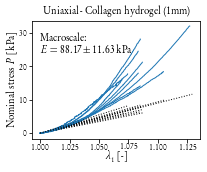

In [3]:
# compute moduli from ua tests
emod_ua = []
lam_max = 1.015
fig_ua = plt.figure()
ax1 = fig_ua.add_subplot(111)
ax1.set_xlabel(r'$\lambda_1$ [-]')
ax1.set_ylabel(r'Nominal stress $P$ [kPa]')

for exp in exp_ua:
    lam1 = exp[:,0]
    sig = exp[:,1]
    idx_max = np.argmin(np.abs(lam1 - lam_max))
    emod = 1e3*np.polyfit(lam1[:idx_max], sig[:idx_max], 1)[0]
    print('E: %.2f' %emod)
    ax1.plot(lam1[:-5], 1e3*sig[:-5], '-', color='C0')
    ax1.plot(lam1, emod*(lam1-1), 'k:')
    emod_ua.append(emod)
    
emod_ua = np.array(emod_ua)
ax1.text(1.0, 30.0, 'Macroscale:\n' r'$E = %.2f \pm %.2f$ kPa' %(np.mean(emod_ua), np.std(emod_ua)), va='top')
ax1.set_title('Uniaxial - Collagen hydrogel (1mm)')

140
          W      pval  normal
0  0.979709  0.035361   False
          W      pval  normal
0  0.982112  0.974253    True


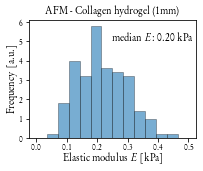

In [4]:
# plot results
print(len(emod_afm))
fig_afm = plt.figure()
ax1 = fig_afm.add_subplot(111)

bins = np.linspace(0, 0.5, 15)
ax1.hist(emod_afm, bins=bins, density=True, alpha=0.6, edgecolor='k', linewidth=0.5)
ax1.set_xlabel('Elastic modulus $E$ [kPa]')
ax1.set_ylabel('Frequency [a.u.]')
ax1.set_title('AFM - Collagen hydrogel (1mm)')
ax1.text(0.25, 5, r'median $E$: %.2f kPa' %(np.median(emod_afm)))

print(pg.normality(emod_afm))
print(pg.normality(emod_ua))



In [5]:
fig_ua.savefig('emod_ua_7dstatic.png', bbox_inches='tight')
fig_afm.savefig('emod_afm_collagen-gel.png', bbox_inches='tight')

### Compare AFM, FT, UA data from UNCOMP, 1 mm, and 0.5 mm gels

In [2]:
def fit_emod_ua(l1, sig, lam_max):
    idx_max = np.argmin(np.abs(l1 - lam_max))
    emod = 1e3*np.polyfit(l1[:idx_max], sig[:idx_max], 1)[0]
    return emod

UNCOMP - UA:
------------
E: 7.04 kPa
E: 4.53 kPa
E: 6.26 kPa
------------

1 mm - UA:
------------
E: 159.19 kPa
E: 163.32 kPa
E: 122.12 kPa
E: 190.81 kPa
E: 160.86 kPa
E: 166.70 kPa
E: 140.66 kPa
E: 162.96 kPa
E: 201.73 kPa
------------

0.5 mm - UA:
------------
E: 520.49 kPa
E: 453.97 kPa
E: 503.62 kPa
E: 728.03 kPa
E: 667.82 kPa
E: 677.87 kPa
E: 532.35 kPa
E: 553.01 kPa
E: 754.36 kPa
------------



Text(0.5, 0.96, 'UA - 0.5 mm')

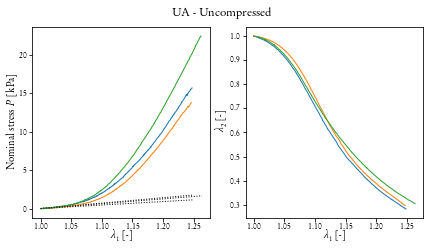

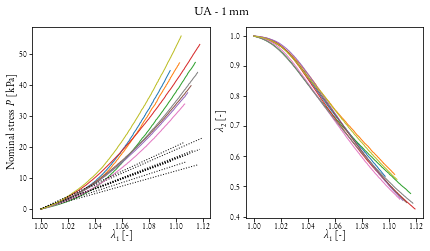

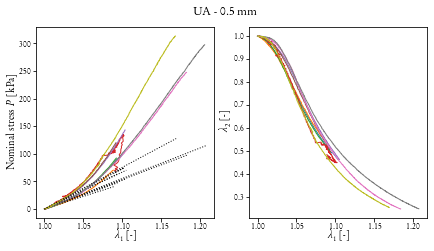

In [3]:
# load UA data
lam_max = 1.02

# umcompressed gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\UA\acell_uncomp_3d\acell_uncomp_3d_1'
uncomp_ua = []
reps = [3, 4, 5]
fig_ua_uncomp = plt.figure(figsize=(7, 3.5))
ax1 = fig_ua_uncomp.add_subplot(121)
ax2 = fig_ua_uncomp.add_subplot(122)
print('UNCOMP - UA:')
print('------------')
for rep in reps:
    # load data
    name = os.path.basename(folder) + '_20200914_UA' + str(rep)
    data = np.loadtxt(os.path.join(folder, name, 'analysis', name + '.dat'), usecols=(1,2,6,))
    
    # fit modulus
    l1 = data[:,0] 
    sig = data[:,2]
    emod = fit_emod_ua(l1, sig, lam_max)
    print('E: %.2f kPa' %emod)
    
    # plot data
    ax1.plot(l1[:-5], 1e3*sig[:-5], '-')
    ax1.plot(l1, emod*(l1-1), 'k:')
    ax2.plot(l1, data[:,1])
    
    # append data
    uncomp_ua.append({'data':data, 'emod':emod})
print('------------\n')

ax1.set_xlabel('$\lambda_1$ [-]')
ax1.set_ylabel('Nominal stress $P$ [kPa]')
ax2.set_xlabel('$\lambda_1$ [-]')
ax2.set_ylabel('$\lambda_2$ [-]')
fig_ua_uncomp.suptitle('UA - Uncompressed', y = 0.96)

# 1 mm gel
folder = r'E:\Research\DynamicCulturingSkinSubstitutes\Experiments\Phase2\15_C_1mm_3d_0d'
abbr = 'C_1mm_3d_0d'
repl = range(1,4)
ua_tests = ['UA1', 'UA2', 'UA3']
fig_ua_1mm = plt.figure(figsize=(7, 3.5))
ax1 = fig_ua_1mm.add_subplot(121)
ax2 = fig_ua_1mm.add_subplot(122)
print('1 mm - UA:')
print('------------')

med_ua = []
for rep in repl:
    sample = '_'.join((abbr, str(rep)))
    for ua in ua_tests:
        # load data
        spec = '_'.join((sample, ua))
        data = np.loadtxt(os.path.join(folder, sample, spec, 'Analysis', 'Ref_0.005N', spec + '_loading_corr.dat'), usecols=(0,1,4,))
        
        # fit modulus
        l1 = data[:,0]
        sig = data[:,2]
        emod = fit_emod_ua(l1, sig, lam_max)
        
        print('E: %.2f kPa' %emod)
    
        # plot data
        ax1.plot(l1[:-5], 1e3*sig[:-5], '-')
        ax1.plot(l1, emod*(l1-1), 'k:')
        ax2.plot(l1, data[:,1])

        # append data
        med_ua.append({'data':data, 'emod':emod})
print('------------\n')

ax1.set_xlabel('$\lambda_1$ [-]')
ax1.set_ylabel('Nominal stress $P$ [kPa]')
ax2.set_xlabel('$\lambda_1$ [-]')
ax2.set_ylabel('$\lambda_2$ [-]')
fig_ua_1mm.suptitle('UA - 1 mm', y = 0.96)

# 0.5 mm gel
folder = r'E:\Research\DynamicCulturingSkinSubstitutes\Experiments\Phase2\20_C_0.25mm_3s_0d_long'
abbr = 'C_0.25mm_3s_0d_long'
repl = range(1,4)
ua_tests = ['UA1', 'UA2', 'UA3']
fig_ua_05mm = plt.figure(figsize=(7, 3.5))
ax1 = fig_ua_05mm.add_subplot(121)
ax2 = fig_ua_05mm.add_subplot(122)
print('0.5 mm - UA:')
print('------------')

high_ua = []
for rep in repl:
    sample = '_'.join((abbr, str(rep)))
    for ua in ua_tests:
        # load data
        spec = '_'.join((sample, ua))
        data = np.loadtxt(os.path.join(folder, sample, spec, 'Analysis', 'Ref_0.005N', spec + '_loading_corr.dat'), usecols=(0,1,4,))
        
        # fit modulus
        l1 = data[:,0]
        sig = data[:,2]
        emod = fit_emod_ua(l1, sig, lam_max)
        
        print('E: %.2f kPa' %emod)
    
        # plot data
        ax1.plot(l1[:-5], 1e3*sig[:-5], '-')
        ax1.plot(l1, emod*(l1-1), 'k:')
        ax2.plot(l1, data[:,1])

        # append data
        high_ua.append({'data':data, 'emod':emod})
print('------------\n')

ax1.set_xlabel('$\lambda_1$ [-]')
ax1.set_ylabel('Nominal stress $P$ [kPa]')
ax2.set_xlabel('$\lambda_1$ [-]')
ax2.set_ylabel('$\lambda_2$ [-]')
fig_ua_05mm.suptitle('UA - 0.5 mm', y = 0.96)


In [39]:
fig_ua_uncomp.savefig('ua_uncomp.pdf', bbox_inches='tight')
fig_ua_1mm.savefig('ua_1mm.pdf', bbox_inches='tight')
fig_ua_05mm.savefig('ua_0.5mm.pdf', bbox_inches='tight')

In [40]:
# load FT data

# uncompressed gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\FT\acell_uncomp_3d_1'
files_ft = glob.glob(os.path.join(folder, 'analysis', 'results', '*.dat'))
uncomp_ft_emods = [np.loadtxt(f)[0,0] for f in files_ft]
print('UNCOMP - FT:')
print('------------')
print('n = %2i' %len(uncomp_ft_emods))
print('median: %.4f kPa' %np.median(uncomp_ft_emods))
print('------------\n')

# 1mm gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\FT\acell_1mm_3d_1'
files_ft = glob.glob(os.path.join(folder, 'analysis', 'results', '*.dat'))
med_ft_emods = [np.loadtxt(f)[0,0] for f in files_ft]

print('1 mm - FT:')
print('------------')
print('n = %2i' %len(med_ft_emods))
print('median: %.4f kPa' %np.median(med_ft_emods))
print('------------\n')

# high gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\FT\acell_0.5mm_3d_1'
files_ft = glob.glob(os.path.join(folder, 'analysis', 'results', '*.dat'))
high_ft_emods = [np.loadtxt(f)[0,0] for f in files_ft]
print('0.5 mm - FT:')
print('------------')
print('n = %2i' %len(high_ft_emods))
print('median: %.4f kPa' %np.median(high_ft_emods))

UNCOMP - FT:
------------
n =  9
median: 0.2820 kPa
------------

1 mm - FT:
------------
n =  9
median: 0.2014 kPa
------------

0.5 mm - FT:
------------
n = 13
median: 0.2448 kPa


In [41]:
# load AFM data

# uncompressed gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\AFM\acell_uncomp_3d\acell_uncomp_3d_1'
files_afm = glob.glob(os.path.join(folder, 'analysis', 'results', '*.dat'))
uncomp_afm_emods = [np.loadtxt(f)[0,0] for f in files_afm]
print('UNCOMP - AFM:')
print('------------')
print('n = %2i' %len(uncomp_afm_emods))
print('median: %.4f kPa' %np.median(uncomp_afm_emods))
print('------------\n')

# 1mm gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\AFM\acell_1mm_3d\acell_1mm_3d_1'
files_afm = glob.glob(os.path.join(folder, 'analysis', 'results', '*.dat'))
med_afm_emods = [np.loadtxt(f)[0,0] for f in files_afm]

print('1 mm - AFM:')
print('------------')
print('n = %2i' %len(med_afm_emods))
print('median: %.4f kPa' %np.median(med_afm_emods))
print('------------\n')

# high gel
folder = r'E:\Research\MultiscaleStiffness\Experiments\CollagenGels\AFM\acell_0.5mm_3d\acell_0.5mm_3d_1'
files_afm = glob.glob(os.path.join(folder, 'analysis', 'results', '*.dat'))
high_afm_emods = [np.loadtxt(f)[0,0] for f in files_afm]
print('0.5 mm - AFM:')
print('------------')
print('n = %2i' %len(high_afm_emods))
print('median: %.4f kPa' %np.median(high_afm_emods))

UNCOMP - AFM:
------------
n = 132
median: 0.3553 kPa
------------

1 mm - AFM:
------------
n = 144
median: 0.4498 kPa
------------

0.5 mm - AFM:
------------
n = 145
median: 0.4830 kPa


[Text(0, 0, 'uncomp.'), Text(0, 0, 'med.'), Text(0, 0, 'high')]

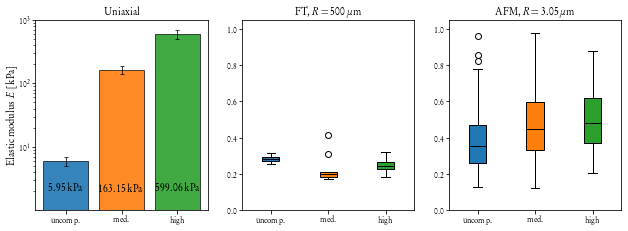

In [98]:
# compare gels and measurements
colconc = [0.002347, 0.0168, 0.0336]
pos = [0, 1, 2]
labels = ['uncomp.', 'med.', 'high']
colors = ['C0', 'C1', 'C2']

fig_comp = plt.figure(figsize=(10.5, 3.5))
ax1 = fig_comp.add_subplot(131)
ax2 = fig_comp.add_subplot(132)
ax3 = fig_comp.add_subplot(133)

means_ua = [np.mean([e['emod'] for e in uncomp_ua]), np.mean([e['emod'] for e in med_ua]), np.mean([e['emod'] for e in high_ua])]
stds_ua = [np.std([e['emod'] for e in uncomp_ua]), np.std([e['emod'] for e in med_ua]), np.std([e['emod'] for e in high_ua])]

for idx in range(3):
    # plot UA
    ax1.bar(idx, means_ua[idx], yerr=stds_ua[idx], alpha=0.9, edgecolor='k', linewidth=0.75, capsize=2, error_kw={'elinewidth':0.75, 'capthick':0.75})
    ax1.text(idx, 2., '%.2f kPa' %(means_ua[idx]), ha='center')
    
# plot FT
box_ft = ax2.boxplot([uncomp_ft_emods, med_ft_emods, high_ft_emods], positions=pos, medianprops={'color':'k'}, patch_artist=True)
for patch, color in zip(box_ft['boxes'], colors):
    patch.set_facecolor(color)
    
# plot AFM
box_afm = ax3.boxplot([uncomp_afm_emods, med_afm_emods, high_afm_emods], positions=pos, medianprops={'color':'k'}, patch_artist=True)
for patch, color in zip(box_afm['boxes'], colors):
    patch.set_facecolor(color)  
    
# set labels and ticks
ax1.set_ylabel('Elastic modulus $E$ [kPa]')
ax1.set_title('Uniaxial')
ax1.set_yscale('log')
ax1.set_yticks([10, 100, 1000])
ax1.set_ylim([1, 1000])
ax1.set_xticks([0, 1, 2])
ax1.set_xticklabels(labels)


ax2.set_title('FT, $R = 500\, \mu$m')
ax2.set_ylim([0, 1.05])
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(labels)

ax3.set_title('AFM, $R = 3.05\, \mu$m')
ax3.set_ylim([0, 1.05])
ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(labels)



In [104]:
fig_comp.savefig('ua-ft-afm_comp.png', bbox_inches='tight', dpi=300)

In [103]:
e = 0.2
f = 4*e/(1-0.5**2)*np.sqrt(3.05)*(0.3*3.05)**1.5/3.
print(f)

0.5434868363937927


Text(0.5, 0.95, 'UA uncompressed')

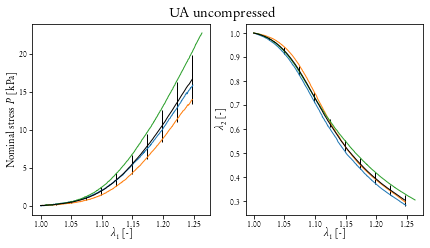

In [18]:
# compute mean UA response of uncompressed gel
l1minmax = np.min([np.max(exp['data'][:,0]) for exp in uncomp_ua])
l1_interp = np.linspace(1.00, l1minmax, 101)
l2_interp = []
sig_interp = []

# prepare figure
fig_ua_uncomp = plt.figure(figsize=(7,3.5))
ax1 = fig_ua_uncomp.add_subplot(121)
ax2 = fig_ua_uncomp.add_subplot(122)

# interpolate experiments to common lambda1
for exp in uncomp_ua:
    l1, l2, sig = exp['data'].T
    l2_interp.append(np.interp(l1_interp, l1, l2))
    sig_interp.append(np.interp(l1_interp, l1, sig))
    ax1.plot(l1, 1e3*sig)
    ax2.plot(l1, l2)
    
# compute mean and std
l2_mean = np.mean(l2_interp, axis=0)
l2_std = np.std(l2_interp, axis=0, ddof=1)
sig_mean = np.mean(sig_interp, axis=0)
sig_std = np.std(sig_interp, axis=0, ddof=1)

# plot mean and std
ax1.errorbar(l1_interp, 1e3*sig_mean, yerr=1e3*sig_std, fmt='k-', errorevery=10)
ax2.errorbar(l1_interp, l2_mean, yerr=l2_std, fmt='k-', errorevery=10)

ax1.set_xlabel('$\lambda_1$ [-]')
ax1.set_ylabel('Nominal stress $P$ [kPa]')
ax2.set_xlabel('$\lambda_1$ [-]')
ax2.set_ylabel('$\lambda_2$ [-]')

fig_ua_uncomp.suptitle('UA uncompressed', y=0.95, fontsize=14)


In [20]:
# save figure
fig_ua_uncomp.savefig('ua_uncomp_mean.pdf', bbox_inches='tight')
# save data
np.savetxt('ua_uncomp_mean.dat', np.c_[l1_interp, l2_mean, l2_std, sig_mean, sig_std])